<a href="https://colab.research.google.com/github/Oswin0905/Logic1/blob/main/connectionism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connectionism
In this assignment, you will implement a connectionist model of memory storage and retrieval. Before starting work on the assigment, you should read the following paper:

- McClelland, J. L. (1981). Retrieving general and specific knowledge from stored knowledge of specifics. *Proceedings of the Third Annual Conference of the Cognitive Science Society,* 170-172. [[link]](https://stanford.edu/~jlmcc/papers/McClelland81.pdf)

Note that all example images in this Colab notebook are just that: example images. Your data can lead to different figures and conclusions than the data used to create these examples.

<figure>
<img src="https://web.stanford.edu/group/pdplab/pdphandbook/jetsdiagram.png" alt="Frequency plot" width=400>
</figure>



In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1. Preparing your data and setting up the network

The dataset listed in the paper consists of 27 gang members with each 6 attributes:


1.   Name (27 unique names)
2.   Gang (2 gangs)
3.   Age (3 age brackets)
4.   Education level (3 education levels)
5.   Marital status (3 marital statuses)
6.   Occupation (3 occupations)

This means that the total number of nodes in our network is $27+27+2+3+3+3+3=68$. Nodes are either excitatory or inhibitory connected to each other. We know from the paper that nodes *within* an attribute inhibit each other. Using a $68 \times 68$ matrix we can encode the complete dataset. To save you time, we are providing a binary matrix as a CSV file, indicating whether or not there is an *excitatory* connection between two nodes.

### Assignment 1.1
Load the data and take a look at its contents. The input is represented as a matrix of size $68 \times 68$. Note that [name]-name refers to a property node, while [name] refers to an instance node.

### Assignment 1.2
Now you will need to represent inhibitory connections between property nodes. Think about your design choices.




In [ ]:
!wget -qO dataset.csv https://surfdrive.surf.nl/files/index.php/s/vxOY3pFjSnP5KoQ/download

# your code here


### Assignment 1.3
It is now time to implement the network as a class named `IACModel`. The class should contain two methods `update_activations()` and `run()` in addition to its special method `__init__()`. You do not yet have to implement the two methods, you will do that later, but you do have to implement `__init__()`. What would you put in there?


In [ ]:
# your code below
class IAC_Node:
    def __init__(self, name, index):
        self.name = name      # [name] refers to an instance node
        self.index = index    # position in the 68-node network
        self.activation = 0.0

    def update_activations(self, activations, weights, external_input, R, D):
        net_input = external_input[self.index] + np.sum(weights[self.index] * activations)
        if net_input >= 0:
            effect = (1 - activations[self.index]) * net_input
        else:
            effect = (activations[self.index] - (-1)) * net_input  # (a - min) * net
        self.activation += effect - D * (activations[self.index] - R)

    def run(self, activations, weights, external_input, R, D, timesteps=500):
        for t in range(timesteps):
            self.update_activations(activations, weights, external_input, R, D)


## Part 2. System dynamics

The *dynamics* of a system refer to its changes in state over time. Each node's activation depends on the activations of the nodes that are connected to it through excitatory and inhibitory connections.

But this is not all. A node's activation *decays* over time, according to $D(a_i(t)-R)$ with decay parameter $D$ and resting value $R$. Let's look at how this works.

### Assignment 2.1

Assume $D=0.05$ and $R=0.1$. Start by implementing a node with activation $A = 0.1$ at time $t=0$. Have the node's activation decay according to the above definition. At time $t=5$ you will excite the node by setting its activation to $0.9$. Run 100 timesteps, then plot the activation over time. This should look something like:


<figure>
<img src="https://surfdrive.surf.nl/files/index.php/s/PCFawx2t62kCzkL/download" alt="Frequency plot" width=400>
</figure>



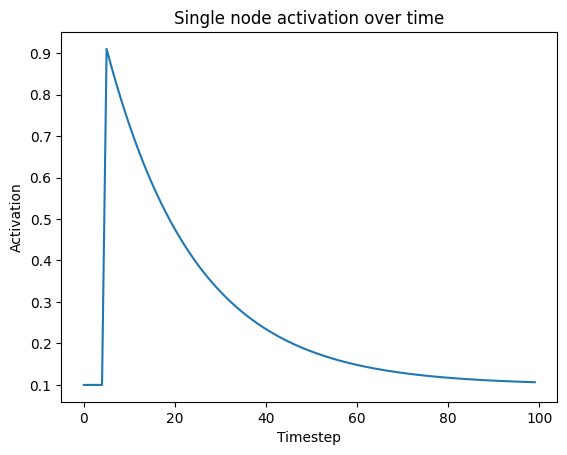

In [ ]:
R = 0.1
D = 0.05
# your code below
import matplotlib.pyplot as plt

R = 0.1
D = 0.05
timesteps = 100

activation = 0.1
activations = [activation]

for t in range(1, timesteps):
    if t == 5:
        external_input = 0.9
    else:
        external_input = 0.0

    net_input = external_input  # single node, no connections

    if net_input >= 0:
        effect = (1 - activation) * net_input
    else:
        effect = (activation - (-1)) * net_input

    activation = activation + effect - D * (activation - R)
    activations.append(activation)

plt.plot(activations)
plt.xlabel('Timestep')
plt.ylabel('Activation')
plt.title('Single node activation over time')
plt.show()

So this is how one node's activation changes over time. Now let's implement our `update_activations()` and `run()` methods to reflect the dynamics described in the paper.

Let's take a look at the paper. Specifically, the net input to node $i$ at time $t$ is given by:

$\textit{input}{_i}(t) = p_i(t) + E\displaystyle\sum_je_{ij}(t) - I\displaystyle\sum_ji_{ij}(t)$

with all necessary symbols explained in the paper (p. 171). In short, the input is determined by (1) the external input going into the system by means of a probe, and (2) the activation of a node's connected neighbors.

Then, once we know $\textit{input}{_i}(t)$, we can calculate $\textit{effect}{_i}(t)$ using this definition from the paper:

<figure>
<img src="https://surfdrive.surf.nl/files/index.php/s/WSFamjOWq6cdU7n/download" alt="Frequency plot" width=600>
</figure>

Finally, we update the activations of our nodes using:

<figure>
<img src="https://surfdrive.surf.nl/files/index.php/s/1RTgbNittDuk46h/download" alt="Frequency plot" width=400>
</figure>

Now you have all the information (together with the paper) to implement the `update_activations()` method in your class. The only thing the `run()` method needs to do is to loop over timesteps (let's say 500) and iteratively call the `update_activations()` method. Implement both.

In [ ]:
# your code below
class IAC_Node:
    def __init__(self, name, index):
        self.name = name
        self.index = index
        self.activation = 0.0

    def update_activations(self, activations, weights, external_input, R, D):
        # Net input: external input to this node + weighted sum from connected nodes
        net_i = external_input[self.index] + np.sum(weights[self.index] * activations)

        # Effect depends on whether net input is excitatory or inhibitory
        if net_i >= 0:
            effect = (1 - activations[self.index]) * net_i
        else:
            effect = (activations[self.index] - (-1)) * net_i

        # Update activation: add effect, apply decay toward resting value R
        activations[self.index] += effect - D * (activations[self.index] - R)

    def run(self, activations, weights, external_input, R, D, timesteps=500):
        for t in range(timesteps):
            self.update_activations(activations, weights, external_input, R, D)

## Part 3. Probing the network and getting information out

For this part, you will create bar graphs of activations. For example, the figure below:


<figure>
<img src="https://surfdrive.surf.nl/files/index.php/s/srMB2wDLzywFo1S/download" alt="Frequency plot" width=400>
</figure>

Let's now take a look at the paper (p. 171) under Examples of the model's behavior.

Probe the network with *Jets*, similar to the paper. Make a figure of the activations of all the property nodes after 500 timesteps.

Now probe the property node of the name *George*. Make a figure of all non-name property nodes.

Finally, probe *Age 20s* and *JH*, similar to the paper. Make a figure showing the activations of the instance nodes.



(69, 69)
(68, 68)


/tmp/ipykernel_6008/1260827215.py:33: RuntimeWarning: overflow encountered in multiply
  (1 - activations) * net_inputs,
/tmp/ipykernel_6008/1260827215.py:34: RuntimeWarning: overflow encountered in multiply
  (activations - (-1)) * net_inputs)
/tmp/ipykernel_6008/1260827215.py:31: RuntimeWarning: invalid value encountered in matmul
  net_inputs = external_input + weights @ activations


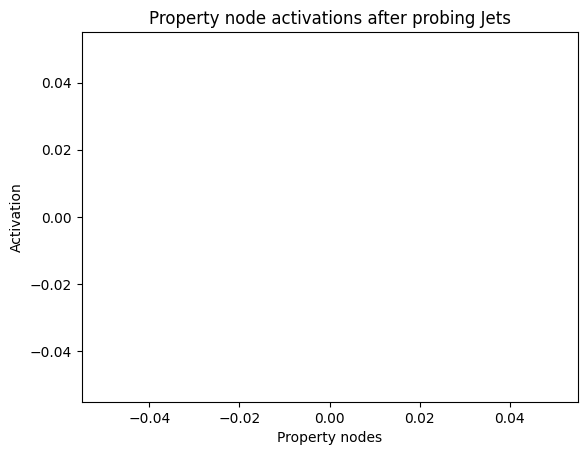

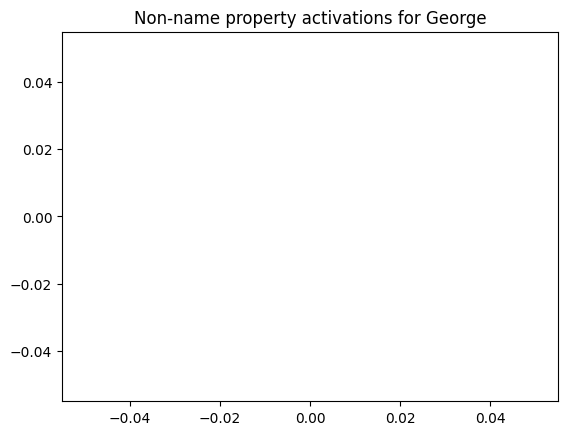

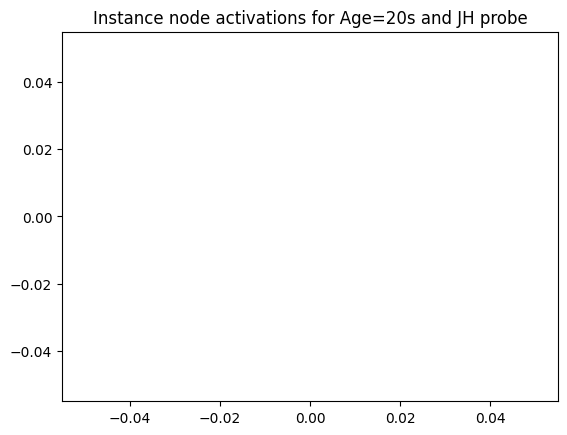

In [ ]:
# your code below


# Assume: dataset loaded, node names list available, Jets/Sharks structure known
# 'name_nodes' = indices of the 27 name nodes
# 'property_nodes' = indices of all property nodes

# Probe with Jets - bar graph of property node activations after 500 timesteps


dataset = np.genfromtxt('dataset.csv', delimiter=',')

# check actual shape
print(dataset.shape)

# if there's a header row/col, strip it
if dataset.shape[0] == 69:
    dataset = dataset[1:, 1:]  # remove first row and first column (labels)

print(dataset.shape)  # should now be (68, 68)

R = 0.1
D = 0.05

def probe_network(probe_index, weights, R, D, timesteps=500):
    activations = np.full(68, R)
    external_input = np.zeros(68)
    external_input[probe_index] = 1.0

    for t in range(timesteps):
        net_inputs = external_input + weights @ activations
        effects = np.where(net_inputs >= 0,
                           (1 - activations) * net_inputs,
                           (activations - (-1)) * net_inputs)
        activations += effects - D * (activations - R)
    return activations

# Probe Jets - bar graph of property node activations
jets_probe_idx = 0
activations = probe_network(jets_probe_idx, dataset, R, D)
plt.bar(range(41), activations[27:])
plt.xlabel('Property nodes')
plt.ylabel('Activation')
plt.title('Property node activations after probing Jets')
plt.show()

# Probe George - bar graph of all non-name property nodes
george_idx = 5
activations_george = probe_network(george_idx, dataset, R, D)
plt.bar(range(14), activations_george[54:])
plt.title('Non-name property activations for George')
plt.show()

# Probe Age=20s and JH - bar graph of instance node activations
age_20s_idx = 40
activations_probe = probe_network(age_20s_idx, dataset, R, D)
plt.bar(range(27), activations_probe[:27])
plt.title('Instance node activations for Age=20s and JH probe')
plt.show()

## Conclusion
Well done! You have implemented McClellands original IAC network, the (re-)birth of connectionism and artificial neural networks!